# 03 · Modelo supervisado

**Objetivo del notebook:** entrenar y comparar modelos de clasificación con validación cronológica, optimizar el mejor con Optuna, elegir un umbral de decisión y explicar sus predicciones con SHAP.

Los hiperparámetros y el umbral se eligen sobre un conjunto de validación, de modo que el conjunto de prueba se usa una sola vez, al final, para estimar el desempeño en transacciones futuras.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import confusion_matrix, precision_recall_curve
from fraude import base_datos as bd, config, datos, graficos, modelo, pipeline
graficos.estilo()

# Carga de datos

In [2]:
conn = bd.conectar()
datos.crear_features(conn)   # Crea la tabla si el notebook 01 no se ha ejecutado

# Cortes cronológicos 60/20/20, calculados en SQL por posición en el tiempo
cortes = datos.cortes_temporales(conn)

# Columnas con ≤50% de nulos en el periodo de entrenamiento, calculado en SQL
utiles = datos.columnas_utiles(conn, hasta_dt=cortes[0])

df = datos.cargar_datos(conn, utiles['transacciones'], utiles['identidad'])
conn.close()

print(f"Columnas excluidas por >50% nulos en entrenamiento: {len(utiles['excluidas'])}")
print(f"Columnas de identidad conservadas: {len(utiles['identidad'])}")
print(f"Dataset de modelado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"  de ellas, variables SQL de comportamiento: {len(datos.FEATURES_SQL)}")
print(f"Tasa de fraude: {df['isFraud'].mean()*100:.2f}%")

Columnas excluidas por >50% nulos en entrenamiento: 230
Columnas de identidad conservadas: 0
Dataset de modelado: 590,540 filas x 213 columnas
  de ellas, variables SQL de comportamiento: 9
Tasa de fraude: 3.50%


# Particionamiento Temporal

In [3]:
# Split cronológico en tres partes para evitar data leakage temporal:
# entrenamiento para ajustar, validación para elegir hiperparámetros y umbral,
# prueba para la evaluación final

df_train, df_valid, df_test = datos.particion_cronologica(df, cortes)
del df

for nombre, parte in [('Train', df_train), ('Valid', df_valid), ('Test', df_test)]:
    dia_ini, dia_fin = parte['TransactionDT'].min() // 86400, parte['TransactionDT'].max() // 86400
    print(f"{nombre:<5}: {len(parte):>7,} filas | Fraude: {parte['isFraud'].mean()*100:.2f}% | días {dia_ini:.0f} a {dia_fin:.0f}")

Train: 354,324 filas | Fraude: 3.38% | días 1 a 101
Valid: 118,108 filas | Fraude: 3.90% | días 101 a 141
Test : 118,108 filas | Fraude: 3.44% | días 141 a 182


La partición cronológica deja 354,324 transacciones para entrenamiento (días 1 a 101), 118,108 para validación (días 101 a 141) y 118,108 para prueba (días 141 a 182). La tasa de fraude es parecida en los tres conjuntos, entre 3.38% y 3.90%, por lo que las diferencias de desempeño entre ellos no se explican por un cambio en la proporción de fraude.

Adicionalmente, todas las decisiones del modelado (qué modelo optimizar, sus hiperparámetros y el umbral de decisión) se toman en validación, ya que elegirlas mirando el mismo conjunto con el que se reporta el desempeño produce una estimación optimista (Cawley & Talbot, 2010). De esta forma, la prueba se usa una sola vez y simula cómo se comportaría el modelo con transacciones futuras.

# Transformadores personalizados

Los transformadores viven en `src/fraude/pipeline.py`, de modo que el pipeline guardado al final se puede cargar desde cualquier notebook. La imputación depende de la familia de cada variable:

- Las variables `D` e `id_` numéricas se imputan con -1 y no con 0, porque 0 es un valor válido en las `D` (misma fecha) y el -1 conserva la ausencia como señal.
- Las variables `C` se imputan con 0, porque son conteos y un nulo equivale a cero ocurrencias; las `V` y el resto de numéricas, con la mediana del entrenamiento, y las categóricas, con la moda.
- Las familias se identifican con el patrón completo del nombre (`D1`, `C13`, `id_02`), para que columnas como `DeviceType` no se confundan con las variables `D`.
- Las variables SQL sin historial reciben valores neutros (z-score de 0, razón de 1, tiempo desde la anterior de -1) y no pasan por el filtro de nulos, porque en ellas un nulo no es un dato perdido sino una tarjeta nueva.

# Ensamblaje del Pipeline

In [4]:
excluir_siempre = [config.ID, config.OBJETIVO]

X_train = df_train.drop(columns=excluir_siempre)
X_valid = df_valid.drop(columns=excluir_siempre)
X_test = df_test.drop(columns=excluir_siempre)
y_train = df_train['isFraud'].values
y_valid = df_valid['isFraud'].values
y_test = df_test['isFraud'].values

# Las listas de columnas numéricas y categóricas se obtienen del entrenamiento
pipeline_maestro = pipeline.construir_pipeline(X_train)

for nombre, paso in pipeline_maestro.steps:
    print(f"  {nombre:<14} {type(paso).__name__}")
print("Pipeline ensamblado correctamente.")

  temporales     CreadorFeaturesTemporales
  log_monto      TransformadorLogMonto
  eliminar_dt    EliminadorColumnas
  excluir_nulos  ExclusorNulos
  imputador      ImputadorAML
  preprocesador  ColumnTransformer
Pipeline ensamblado correctamente.


# Aplicación del Pipeline

In [5]:
# Las matrices se guardan en float32 para reducir a la mitad la memoria
print("Aplicando Pipeline sobre Train...")
X_train_proc = pipeline_maestro.fit_transform(X_train).astype(np.float32)

print("Aplicando Pipeline sobre Valid y Test...")
X_valid_proc = pipeline_maestro.transform(X_valid).astype(np.float32)
X_test_proc = pipeline_maestro.transform(X_test).astype(np.float32)
del X_train, X_valid, X_test

nombres = pipeline.nombres_salida(pipeline_maestro)
cat_cols = pipeline_maestro.named_steps['preprocesador'].transformers_[1][2]

print(f"\nTrain procesado: {X_train_proc.shape}")
print(f"Valid procesado: {X_valid_proc.shape}")
print(f"Test procesado: {X_test_proc.shape}")
print(f"Columnas numéricas: {len(nombres) - len(cat_cols)} | categóricas: {len(cat_cols)} {cat_cols}")

print("\nVerificación post-pipeline:")
for nombre, X in [('Train', X_train_proc), ('Valid', X_valid_proc), ('Test', X_test_proc)]:
    nans = np.isnan(X).sum()
    infs = np.isinf(X).sum()
    status = 'OK' if nans == 0 and infs == 0 else 'REVISAR'
    print(f" {nombre} — NaNs: {nans} | Infs: {infs} | {status}")

ratio = modelo.razon_desbalance(y_train)
print(f"\nRatio desbalance: {ratio:.1f}:1")
print(f"scale_pos_weight: {ratio:.2f}")

Aplicando Pipeline sobre Train...


Aplicando Pipeline sobre Valid y Test...



Train procesado: (354324, 212)
Valid procesado: (118108, 212)
Test procesado: (118108, 212)
Columnas numéricas: 206 | categóricas: 6 ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M4', 'M6']

Verificación post-pipeline:


 Train — NaNs: 0 | Infs: 0 | OK
 Valid — NaNs: 0 | Infs: 0 | OK
 Test — NaNs: 0 | Infs: 0 | OK

Ratio desbalance: 28.6:1
scale_pos_weight: 28.56


# Comparación de modelos baseline

Entrenamiento de los cuatro modelos: 5.3 min

---Comparativa baseline (validación)---
             Modelo  ROC-AUC  PR-AUC  GINI
           LightGBM   0.9055  0.5513 81.10
      Random Forest   0.9011  0.5507 80.22
            XGBoost   0.8767  0.5326 75.34
Logistic Regression   0.7636  0.1486 52.73


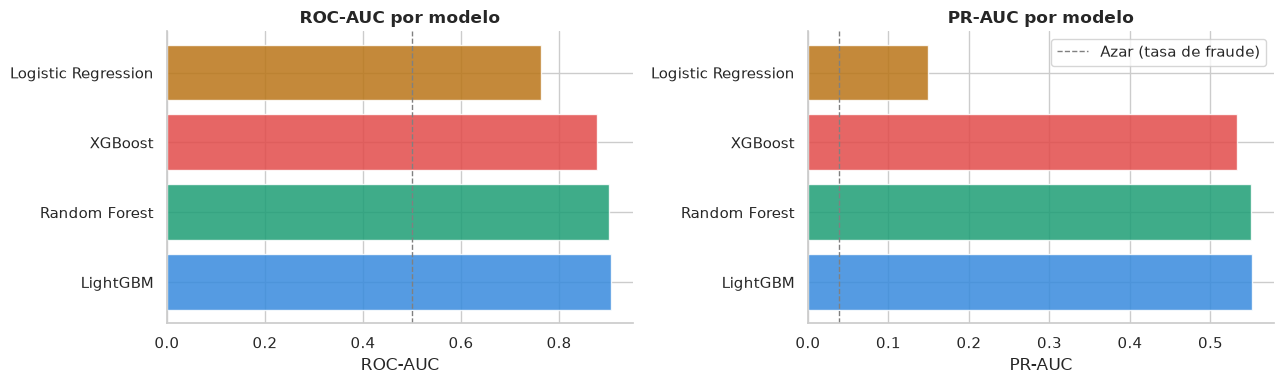

In [6]:
# Los cuatro modelos se entrenan con Train y se comparan en Valid

inicio = time.perf_counter()
df_resultados, ajustados = modelo.comparar(
    modelo.modelos_base(ratio), X_train_proc, y_train, X_valid_proc, y_valid)
print(f"Entrenamiento de los cuatro modelos: {(time.perf_counter() - inicio)/60:.1f} min")

print("\n---Comparativa baseline (validación)---")
print(df_resultados.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(df_resultados['Modelo'], df_resultados['ROC-AUC'],
             color=graficos.PALETA, alpha=0.85)
axes[0].axvline(0.5, color='gray', linestyle='--', lw=1)
axes[0].set_title('ROC-AUC por modelo')
axes[0].set_xlabel('ROC-AUC')
sns.despine(ax=axes[0])

axes[1].barh(df_resultados['Modelo'], df_resultados['PR-AUC'],
             color=graficos.PALETA, alpha=0.85)
axes[1].axvline(y_valid.mean(), color='gray', linestyle='--', lw=1, label='Azar (tasa de fraude)')
axes[1].set_title('PR-AUC por modelo')
axes[1].set_xlabel('PR-AUC')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
graficos.guardar(fig, '03_baseline')
plt.show()

En la comparación sobre validación, LightGBM obtiene el mejor PR-AUC (0.5513), prácticamente empatado con Random Forest (0.5507), mientras que XGBoost queda en 0.5326 y la regresión logística en 0.1486. Los tres modelos basados en árboles superan por más de trece veces el PR-AUC de un modelo al azar, que es igual a la tasa de fraude de validación (3.90%), lo que confirma que la combinación de variables sí separa el fraude aunque ninguna lo haga por sí sola.

Por su parte, la distancia de la regresión logística (ROC-AUC de 0.7636) indica que la relación entre las variables y el fraude no es lineal, por lo que los modelos de árboles son la opción natural para este problema. Se escoge LightGBM (Ke et al., 2017) para la optimización porque lidera en ambas métricas, aunque con una ventaja mínima sobre Random Forest.

# Optimización con Optuna

In [7]:
# El modelo con mayor PR-AUC en el baseline es el candidato a optimizar.
# Se identifica antes de definir el espacio de búsqueda.

mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
pr_baseline = df_resultados.iloc[0]['PR-AUC']
print(f"Modelo seleccionado para optimizar: {mejor_modelo_nombre}")
print(f"PR-AUC baseline (validación): {pr_baseline:.4f}")

Modelo seleccionado para optimizar: LightGBM
PR-AUC baseline (validación): 0.5513


Iniciando optimización bayesiana (20 trials)...


Duración: 8.6 min

Mejor PR-AUC en validación: 0.5668
Mejora sobre baseline: 0.0155

Mejores hiperparámetros:
  n_estimators             : 299
  max_depth                : 10
  learning_rate            : 0.09548424890644631
  num_leaves               : 59
  subsample                : 0.5328424773692201
  colsample_bytree         : 0.6320843927947588
  lambda_l1                : 8.189267679407083e-08
  lambda_l2                : 8.215000260278623


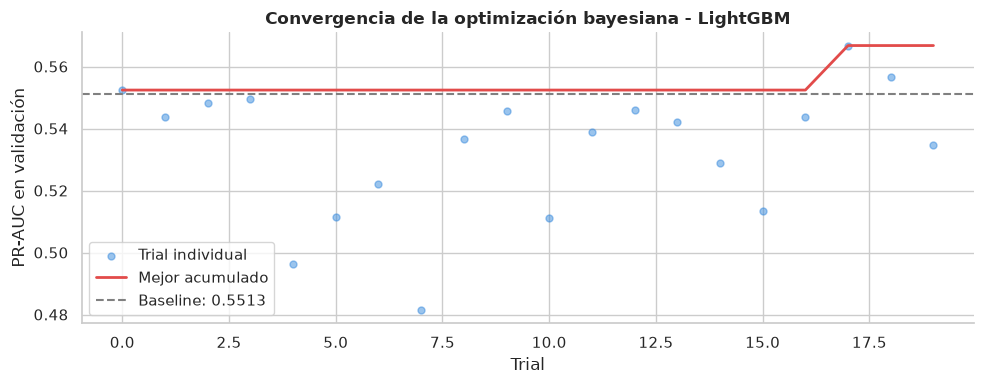

In [8]:
# Cada trial se entrena con Train y se evalúa en Valid; Test no interviene

print("Iniciando optimización bayesiana (20 trials)...")
inicio = time.perf_counter()
study = modelo.optimizar_lightgbm(X_train_proc, y_train, X_valid_proc, y_valid, n_trials=20)
print(f"Duración: {(time.perf_counter() - inicio)/60:.1f} min")

print(f"\nMejor PR-AUC en validación: {study.best_value:.4f}")
print(f"Mejora sobre baseline: {(study.best_value - pr_baseline):.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k:<25}: {v}")

# Visualización de convergencia
trials_df = study.trials_dataframe()
trials_df['mejor_acumulado'] = trials_df['value'].cummax()

fig = plt.figure(figsize=(10, 4))
plt.scatter(trials_df.index, trials_df['value'],
            color=graficos.AZUL, alpha=0.5, s=25, label='Trial individual')
plt.plot(trials_df.index, trials_df['mejor_acumulado'],
         color=graficos.ROJO, lw=2, label='Mejor acumulado')
plt.axhline(pr_baseline, color='gray',
            linestyle='--', lw=1.5, label=f'Baseline: {pr_baseline:.4f}')
plt.title('Convergencia de la optimización bayesiana - LightGBM')
plt.xlabel('Trial')
plt.ylabel('PR-AUC en validación')
plt.legend()
sns.despine()
plt.tight_layout()
graficos.guardar(fig, '03_optuna')
plt.show()

La optimización bayesiana con 20 trials (Akiba et al., 2019) mejora el PR-AUC de validación de 0.5513 a 0.5668, es decir, 0.0155 puntos. La mejora es modesta, lo que sugiere que con sus valores por defecto LightGBM ya estaba cerca de su techo con estas variables y que el margen de mejora está más en los datos que en los hiperparámetros.

Los hiperparámetros elegidos combinan árboles profundos (max_depth de 10 y 59 hojas) con una regularización L2 alta (lambda_l2 de 8.2) y un submuestreo del 53% de las filas y el 63% de las columnas en cada árbol, una configuración que busca capturar interacciones complejas sin memorizar el entrenamiento.

# Modelo final

In [9]:
# Modelo de selección: hiperparámetros de Optuna, entrenado solo con Train.
# Sirve para medir Valid, diagnosticar sobreajuste y fijar el umbral.
modelo_seleccion = modelo.lightgbm(study.best_params)
modelo_seleccion.fit(X_train_proc, y_train)
proba_train = modelo_seleccion.predict_proba(X_train_proc)[:, 1]
proba_valid = modelo_seleccion.predict_proba(X_valid_proc)[:, 1]

# Modelo final: mismos hiperparámetros, reentrenado con Train + Valid para
# aprovechar los 40 días más recientes antes de Test. Test se usa aquí por primera vez.
X_tv_proc = np.vstack([X_train_proc, X_valid_proc])
y_tv = np.concatenate([y_train, y_valid])
modelo_final = modelo.lightgbm(study.best_params)
modelo_final.fit(X_tv_proc, y_tv)
proba_tv = modelo_final.predict_proba(X_tv_proc)[:, 1]
proba_test = modelo_final.predict_proba(X_test_proc)[:, 1]

# Referencia: el modelo de selección evaluado en Test, sin los datos de Valid
proba_test_seleccion = modelo_seleccion.predict_proba(X_test_proc)[:, 1]

metricas_finales = pd.DataFrame([
    {'Modelo': 'Selección (Train)', 'Conjunto': 'Train', **modelo.metricas(y_train, proba_train)},
    {'Modelo': 'Selección (Train)', 'Conjunto': 'Valid', **modelo.metricas(y_valid, proba_valid)},
    {'Modelo': 'Selección (Train)', 'Conjunto': 'Test', **modelo.metricas(y_test, proba_test_seleccion)},
    {'Modelo': 'Final (Train + Valid)', 'Conjunto': 'Train + Valid', **modelo.metricas(y_tv, proba_tv)},
    {'Modelo': 'Final (Train + Valid)', 'Conjunto': 'Test', **modelo.metricas(y_test, proba_test)},
])

print("--- Métricas ---")
print(metricas_finales.to_string(index=False))
brecha = metricas_finales['ROC-AUC'].iloc[3] - metricas_finales['ROC-AUC'].iloc[4]
print(f"\nBrecha entrenamiento-Test del modelo final (ROC-AUC): {brecha*100:.2f} pts")
print(f"PR-AUC de un modelo al azar en Test: {y_test.mean():.4f}")

--- Métricas ---
               Modelo      Conjunto  ROC-AUC  PR-AUC  GINI
    Selección (Train)         Train   0.9887  0.8369 97.74
    Selección (Train)         Valid   0.9134  0.5668 82.68
    Selección (Train)          Test   0.8686  0.4503 73.72
Final (Train + Valid) Train + Valid   0.9836  0.8011 96.71
Final (Train + Valid)          Test   0.9085  0.5029 81.69

Brecha entrenamiento-Test del modelo final (ROC-AUC): 7.51 pts
PR-AUC de un modelo al azar en Test: 0.0344


El modelo de selección muestra una brecha importante entre entrenamiento y validación (PR-AUC de 0.8369 frente a 0.5668), y su desempeño sigue bajando en prueba (0.4503). Esta caída no es solo sobreajuste, ya que en fraude el comportamiento cambia con el tiempo y un modelo pierde capacidad a medida que se aleja del periodo con el que se entrenó (Dal Pozzolo et al., 2018). Por esa razón el modelo final se reentrena con entrenamiento y validación juntos, y al incluir los 40 días más recientes antes de la prueba el PR-AUC en prueba sube de 0.4503 a 0.5029 y el ROC-AUC de 0.8686 a 0.9085.

En conclusión, el modelo final alcanza en prueba un PR-AUC 14.6 veces superior al de un modelo al azar (0.0344), con una brecha de ROC-AUC entre entrenamiento y prueba de 7.51 puntos, que es la estimación honesta de su desempeño sobre transacciones futuras.

# Aporte de las variables SQL

In [10]:
# Se reentrena el modelo final con y sin las variables construidas en SQL, en dos
# escenarios: con todas las columnas del dataset y sin las familias C, D y V, que
# Vesta entrega ya calculadas a partir del historial de cada tarjeta

sql = set(datos.FEATURES_SQL)
proveedor = re.compile(r'^(C|D|V)\d+$')
escenarios = {
    ('Todas las columnas', 'Con SQL'):    [i for i, n in enumerate(nombres)],
    ('Todas las columnas', 'Sin SQL'):    [i for i, n in enumerate(nombres) if n not in sql],
    ('Sin familias C, D y V', 'Con SQL'): [i for i, n in enumerate(nombres) if not proveedor.match(n)],
    ('Sin familias C, D y V', 'Sin SQL'): [i for i, n in enumerate(nombres) if not proveedor.match(n) and n not in sql],
}

filas = []
for (base, variante), idx in escenarios.items():
    if (base, variante) == ('Todas las columnas', 'Con SQL'):
        proba = proba_test
    else:
        m = modelo.lightgbm(study.best_params).fit(X_tv_proc[:, idx], y_tv)
        proba = m.predict_proba(X_test_proc[:, idx])[:, 1]
    filas.append({'Columnas': base, 'Variables SQL': variante, 'Variables': len(idx),
                  **modelo.metricas(y_test, proba)})

aporte = pd.DataFrame(filas)
print("--- Test ---")
print(aporte.to_string(index=False))
for base in ('Todas las columnas', 'Sin familias C, D y V'):
    par = aporte[aporte['Columnas'] == base].set_index('Variables SQL')
    print(f"\n{base}: aporte SQL en ROC-AUC {par.loc['Con SQL', 'ROC-AUC'] - par.loc['Sin SQL', 'ROC-AUC']:+.4f}"
          f" | en PR-AUC {par.loc['Con SQL', 'PR-AUC'] - par.loc['Sin SQL', 'PR-AUC']:+.4f}")

--- Test ---
             Columnas Variables SQL  Variables  ROC-AUC  PR-AUC  GINI
   Todas las columnas       Con SQL        212   0.9085  0.5029 81.69
   Todas las columnas       Sin SQL        203   0.9070  0.5102 81.40
Sin familias C, D y V       Con SQL         24   0.8460  0.2359 69.21
Sin familias C, D y V       Sin SQL         15   0.8234  0.2244 64.68

Todas las columnas: aporte SQL en ROC-AUC +0.0015 | en PR-AUC -0.0073

Sin familias C, D y V: aporte SQL en ROC-AUC +0.0226 | en PR-AUC +0.0115


El resultado de este experimento es que, con todas las columnas del dataset, las variables SQL no mejoran el modelo: el ROC-AUC sube apenas 0.0015 y el PR-AUC baja 0.0073. La explicación está en el segundo escenario, ya que al quitar las familias C, D y V las variables SQL sí aportan 0.0226 de ROC-AUC y 0.0115 de PR-AUC. Es decir, Vesta ya entrega en esas familias conteos y tiempos calculados a partir del historial de cada tarjeta (Vesta Corporation, 2019), que contienen la misma información que reconstruyen las ventanas de SQL, por lo que sobre ellas las variables nuevas resultan redundantes.

Aun así, se mantienen en el modelo final porque la decisión de incluirlas se tomó antes de mirar la prueba y porque, a diferencia de las variables V, que llegan anonimizadas, las variables SQL tienen una definición conocida y auditable. Adicionalmente, el escenario sin las familias C, D y V muestra que, en un sistema donde el proveedor no entregue esas variables, las ventanas de SQL son las que aportan la información de comportamiento de la tarjeta.

# Umbral de decisión

Umbral elegido en validación: 0.8066
  Valid — precisión 0.658 | recall 0.480 | F1 0.555


  Test  — precisión 0.550 | recall 0.455 | F1 0.498
  Alertas en Test: 2.85% de las transacciones
  Fraudes detectados: 1,850 de 4,064 | falsas alarmas: 1,515


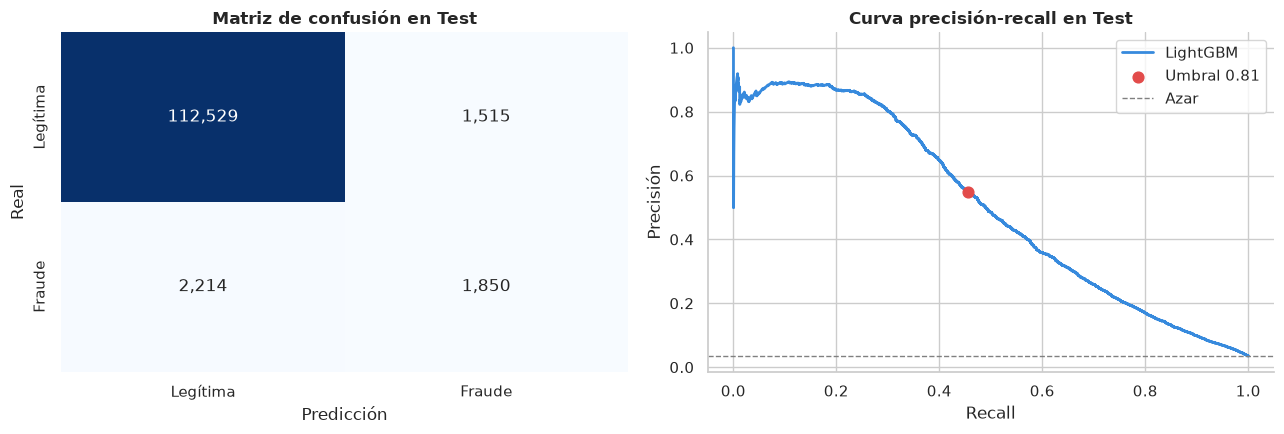

               Revisión  alertas  fraudes  precision  recall
1% de las transacciones     1181     1009      0.854   0.248
2% de las transacciones     2362     1574      0.666   0.387
5% de las transacciones     5905     2337      0.396   0.575


In [11]:
# El umbral se elige en Valid (máximo F1) con el modelo de selección y se aplica
# sin cambios al modelo final en Test

elegido = modelo.umbral_f1(y_valid, proba_valid)
print(f"Umbral elegido en validación: {elegido['umbral']:.4f}")
print(f"  Valid — precisión {elegido['precision']:.3f} | recall {elegido['recall']:.3f} | F1 {elegido['f1']:.3f}")

resultado = modelo.evaluar_umbral(y_test, proba_test, elegido['umbral'])
print(f"  Test  — precisión {resultado['precision']:.3f} | recall {resultado['recall']:.3f} | F1 {resultado['f1']:.3f}")
print(f"  Alertas en Test: {resultado['tasa_alertas']*100:.2f}% de las transacciones")
print(f"  Fraudes detectados: {resultado['vp']:,} de {resultado['vp'] + resultado['fn']:,} | falsas alarmas: {resultado['fp']:,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

matriz = confusion_matrix(y_test, (proba_test >= elegido['umbral']).astype(int))
sns.heatmap(matriz, annot=True, fmt=',', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
axes[0].set_title('Matriz de confusión en Test')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

precision, recall, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(recall, precision, color=graficos.AZUL, lw=2, label='LightGBM')
axes[1].scatter(resultado['recall'], resultado['precision'], color=graficos.ROJO, s=60, zorder=3,
                label=f"Umbral {elegido['umbral']:.2f}")
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', lw=1, label='Azar')
axes[1].set_title('Curva precisión-recall en Test')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisión')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
graficos.guardar(fig, '03_umbral')
plt.show()

# Captura de fraude si el equipo de revisión solo puede atender una fracción de las transacciones
presupuestos = pd.DataFrame([
    {'Revisión': f'{p*100:.0f}% de las transacciones', **modelo.captura_por_presupuesto(y_test, proba_test, p)}
    for p in (0.01, 0.02, 0.05)])
presupuestos[['precision', 'recall']] = presupuestos[['precision', 'recall']].round(3)
print(presupuestos.to_string(index=False))

Con el umbral elegido en validación (0.81), el modelo final detecta en prueba 1,850 de los 4,064 fraudes (recall de 0.455) con una precisión de 0.550, es decir, poco más de la mitad de las alertas son fraudes reales, a costa de 1,515 falsas alarmas sobre 114,044 transacciones legítimas. Sin embargo, el F1 de prueba (0.498) queda por debajo del de validación (0.555), lo que muestra que el umbral también pierde vigencia con el tiempo y que en operación debería recalibrarse periódicamente.

Adicionalmente, la tabla de presupuestos muestra que la utilidad del modelo depende de cuántas alertas pueda revisar el equipo de fraude: si solo se revisa el 1% de las transacciones con mayor puntaje, el 85.4% de las alertas son fraudes y se captura el 24.8% del fraude, mientras que revisando el 5% se captura el 57.5% con una precisión de 39.6%. Este tipo de lectura, que mide la precisión de las alertas que realmente se revisan, es más cercana a cómo se evalúa un sistema de detección de fraude en la práctica que una métrica global (Dal Pozzolo et al., 2018).

# Interpretabilidad con SHAP

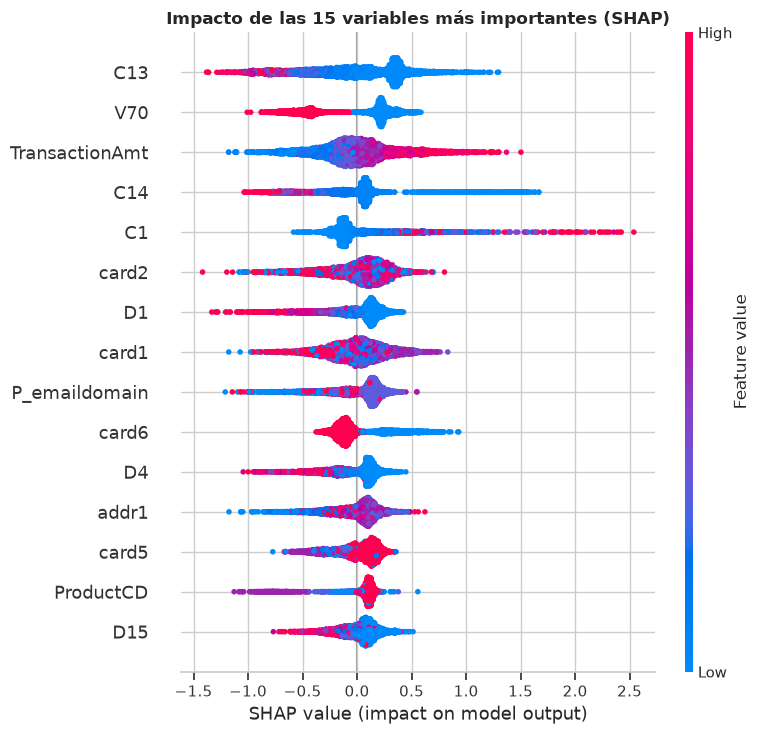

                SHAP medio |abs|   origen
C13                       0.3561  dataset
V70                       0.3370  dataset
TransactionAmt            0.2556  dataset
C14                       0.2335  dataset
C1                        0.2124  dataset
card2                     0.2063  dataset
D1                        0.1951  dataset
card1                     0.1949  dataset
P_emaildomain             0.1872  dataset
card6                     0.1787  dataset
D4                        0.1733  dataset
addr1                     0.1548  dataset
card5                     0.1482  dataset
ProductCD                 0.1355  dataset
D15                       0.1315  dataset

Posición de las variables SQL en el ranking (de 212 variables):
seg_desde_anterior    20
monto_prom_previo     31
ratio_monto_previo    34
tx_previas            37
z_monto_previo        49
tx_24h                86
monto_24h             87
tx_1h                 88
tiene_identidad       89


In [12]:
# SHAP del modelo final sobre una muestra aleatoria de 5,000 transacciones de Test

rng = np.random.default_rng(config.SEMILLA)
muestra_idx = rng.choice(len(X_test_proc), size=5000, replace=False)
muestra = pd.DataFrame(X_test_proc[muestra_idx], columns=nombres)

explainer = shap.TreeExplainer(modelo_final)
valores_shap = explainer.shap_values(muestra)
if isinstance(valores_shap, list):
    valores_shap = valores_shap[1]

shap.summary_plot(valores_shap, muestra, max_display=15, show=False)
fig = plt.gcf()
plt.title('Impacto de las 15 variables más importantes (SHAP)')
plt.tight_layout()
graficos.guardar(fig, '03_shap')
plt.show()

importancia = (pd.Series(np.abs(valores_shap).mean(axis=0), index=nombres)
               .sort_values(ascending=False))
ranking = importancia.rank(ascending=False).astype(int)
top = importancia.head(15).to_frame('SHAP medio |abs|').round(4)
top['origen'] = ['SQL' if n in datos.FEATURES_SQL else 'dataset' for n in top.index]
print(top.to_string())
print("\nPosición de las variables SQL en el ranking (de", len(nombres), "variables):")
print(ranking[datos.FEATURES_SQL].sort_values().to_string())

El análisis SHAP (Lundberg et al., 2020) muestra que las variables más influyentes son conteos y tiempos de Vesta (C13, C14, C1, D1, D4 y D15), una variable V (V70), el monto, las características de la tarjeta (card1, card2, card5 y card6), el dominio de email del comprador y el tipo de producto. En C1 los valores altos empujan la predicción hacia fraude, mientras que en C13, C14 y D1 son los valores bajos los que aumentan el riesgo, lo que sugiere que las tarjetas con poco historial y con una relación reciente son más riesgosas. En el monto, los valores altos tienden a aumentar el riesgo, lo que es consistente con la mayor presencia de fraude en los montos altos que se observó en el EDA.

Por su parte, la variable SQL mejor ubicada es el tiempo desde la transacción anterior, en el puesto 20 de 212, seguida del monto promedio previo (31) y de la razón frente a ese promedio (34), mientras que la bandera de identidad queda en el puesto 89. Esto es consistente con el experimento anterior, ya que las variables SQL sí contienen señal, pero el modelo prefiere las variables de Vesta que miden lo mismo.

# Guardado del modelo

In [13]:
# Pipeline, modelo, umbral y columnas se guardan juntos para que el notebook 04
# (o cualquier script) aplique exactamente el mismo preprocesamiento

paquete = {
    'pipeline': pipeline_maestro,
    'modelo': modelo_final,
    'umbral': elegido['umbral'],
    'hiperparametros': study.best_params,
    'cortes': cortes,
    'columnas': {'transacciones': utiles['transacciones'], 'identidad': utiles['identidad']},
    'nombres': nombres,
}
ruta = modelo.guardar(paquete, 'modelo_lightgbm.joblib')
print(f"Modelo guardado en {ruta.relative_to(config.RAIZ)} ({ruta.stat().st_size / 1024**2:.1f} MB)")

Modelo guardado en outputs/modelos/modelo_lightgbm.joblib (1.9 MB)


# Conclusiones

- El modelo final, un LightGBM optimizado con Optuna y reentrenado con entrenamiento y validación, alcanza en prueba un PR-AUC de 0.5029 y un ROC-AUC de 0.9085, con un PR-AUC 14.6 veces superior al de un modelo al azar.
- La validación cronológica en tres conjuntos fue determinante para obtener una estimación honesta: los hiperparámetros y el umbral se eligieron sin mirar la prueba, y reentrenar con los 40 días más recientes subió el PR-AUC de prueba de 0.4503 a 0.5029, lo que muestra que en fraude la recencia de los datos pesa tanto como el algoritmo.
- Con el umbral de máximo F1 el modelo detecta el 45.5% del fraude con una precisión del 55%, y si el equipo de revisión solo puede atender el 1% de las transacciones, el 85.4% de sus alertas serían fraudes.
- Las variables de comportamiento construidas en SQL no mejoran el modelo cuando están disponibles las familias C, D y V de Vesta, porque contienen la misma información; sin esas familias sí aportan (+0.0226 de ROC-AUC), lo que las hace útiles en un sistema donde el comportamiento de la tarjeta deba construirse desde las transacciones.
- El siguiente paso es comparar este modelo con un detector no supervisado (notebook 04), que no depende de las etiquetas de fraude, las cuales en la práctica llegan con días o semanas de retraso (Dal Pozzolo et al., 2018).

## Referencias

- Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. En *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining* (pp. 2623–2631). https://doi.org/10.1145/3292500.3330701
- Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107.
- Dal Pozzolo, A., Boracchi, G., Caelen, O., Alippi, C., & Bontempi, G. (2018). Credit card fraud detection: A realistic modeling and a novel learning strategy. *IEEE Transactions on Neural Networks and Learning Systems, 29*(8), 3784–3797. https://doi.org/10.1109/TNNLS.2017.2736643
- Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). LightGBM: A highly efficient gradient boosting decision tree. En *Advances in Neural Information Processing Systems 30* (pp. 3146–3154).
- Lundberg, S. M., Erion, G., Chen, H., DeGrave, A., Prutkin, J. M., Nair, B., Katz, R., Himmelfarb, J., Bansal, N., & Lee, S.-I. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence, 2*(1), 56–67. https://doi.org/10.1038/s42256-019-0138-9
- Vesta Corporation. (2019). *Data description (details and discussion)* [Publicación en foro]. Kaggle. https://www.kaggle.com/c/ieee-fraud-detection/discussion/101203